**INFORME DE REGRESION DE CONTAMINANTES EN INTERVALOS DE TIEMPO (2024-2025)**

**1. Introducción**



El ozono troposférico (O₃) es un contaminante secundario formado a partir de reacciones fotoquímicas entre óxidos de nitrógeno (NOₓ) y compuestos orgánicos volátiles (COV) en presencia de radiación solar [1]. A diferencia de los contaminantes primarios, su concentración no depende únicamente de las fuentes de emisión, sino también de factores meteorológicos y procesos químicos complejos en la atmósfera [2].

Diversos estudios han demostrado que la variabilidad temporal del ozono está influenciada por patrones estacionales, condiciones climáticas y dinámicas locales de transporte de contaminantes [1,2]. En este contexto, el modelamiento estadístico constituye una herramienta útil para analizar tendencias y relaciones entre variables ambientales [3].

El presente estudio tiene como objetivo evaluar la capacidad de un modelo de regresión polinómica para describir la evolución temporal de la concentración máxima diaria de ozono (promedio móvil de 8 horas) durante los años 2024 y 2025 en el estado de Nueva York, utilizando como variable independiente el día del año. Este enfoque permite analizar hasta qué punto la variación temporal por sí sola explica el comportamiento del contaminante.

**2. Metodología**

2.1 Datos

Se utilizaron datos de concentración de ozono descargados de **"EPA, United States Environmental Protection Agency"** luego se cargaron a un repositorio en Github en formato CSV correspondientes a los años 2024 y 2025.

2.2 Preprocesamiento

Se hizo los siguientes procesamientos:
 conversión de la variable fecha a formato "datetime"Eliminación de valores

*   Conversión de la variable fecha a formato "datatime"
*   Eliminación de valores nulos
*   Filtrado por estado: New York
*   Selección del sitio con mayor número de observaciones
*   Generación de variable temportal: "día del año"


2.3 Modelo

Se aplicó un modelo de regresión polinómica de grado 3.

2.4 Métricas

Las métricas que se utilizaron son:


*   R²
*   RMSE → error cuadrático medio
*   MAE → error absoluto medio


El código siguiente es del modelo (polinomico)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [8]:
url_2024 = "https://raw.githubusercontent.com/SERGIOSL21/REPO-PROYECTOS/main/DATOS%20O3_2024.csv"
url_2025 = "https://raw.githubusercontent.com/SERGIOSL21/REPO-PROYECTOS/main/DATOS%20O3_2025.csv"

df_2024 = pd.read_csv(url_2024, engine="python", on_bad_lines="skip")
df_2025 = pd.read_csv(url_2025, engine="python", on_bad_lines="skip")

In [9]:
def limpiar_datos(df):
    df = df.copy()

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df["Daily Max 8-hour Ozone Concentration"] = pd.to_numeric(
        df["Daily Max 8-hour Ozone Concentration"], errors="coerce"
    )

    df = df.dropna(subset=["Date", "Daily Max 8-hour Ozone Concentration"])

    # Filtrar por estado
    df = df[df["State"] == "New York"]

    # Elegir estación con más datos
    best_site = df["Site ID"].value_counts().idxmax()
    df = df[df["Site ID"] == best_site]

    # Variable temporal
    df["day_of_year"] = df["Date"].dt.dayofyear

    return df

df_2024 = limpiar_datos(df_2024)
df_2025 = limpiar_datos(df_2025)

In [10]:
def modelo_polinomico(df, degree=3):

    X = df[["day_of_year"]]
    y = df["Daily Max 8-hour Ozone Concentration"]

    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(X)

    model = LinearRegression()
    model.fit(X_poly, y)

    y_pred = model.predict(X_poly)

    # Métricas
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)

    return y, y_pred, X, r2, rmse, mae

y_2024, y_pred_2024, X_2024, r2_2024, rmse_2024, mae_2024 = modelo_polinomico(df_2024)
y_2025, y_pred_2025, X_2025, r2_2025, rmse_2025, mae_2025 = modelo_polinomico(df_2025)


In [16]:
print("RESULTADOS")
print(f"2024 -> R2: {r2_2024:.4f}, RMSE: {rmse_2024:.4f}, MAE: {mae_2024:.4f}")
print(f"2025 -> R2: {r2_2025:.4f}, RMSE: {rmse_2025:.4f}, MAE: {mae_2025:.4f}")

RESULTADOS
2024 -> R2: 0.2957, RMSE: 0.0091, MAE: 0.0067
2025 -> R2: 0.2515, RMSE: 0.0088, MAE: 0.0066


**Ahora tendremos el gráfico del modelo polínomico**





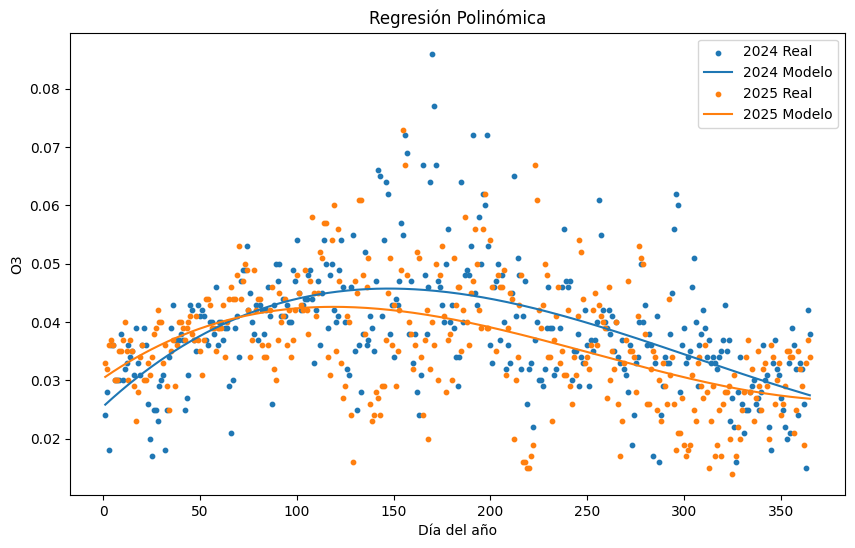

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(X_2024, y_2024, s=10, label="2024 Real")
plt.plot(X_2024, y_pred_2024, label="2024 Modelo")

plt.scatter(X_2025, y_2025, s=10, label="2025 Real")
plt.plot(X_2025, y_pred_2025, label="2025 Modelo")

plt.xlabel("Día del año")
plt.ylabel("O3")
plt.title("Regresión Polinómica")
plt.legend()
plt.show()

Gráfico del valor real vs predicho

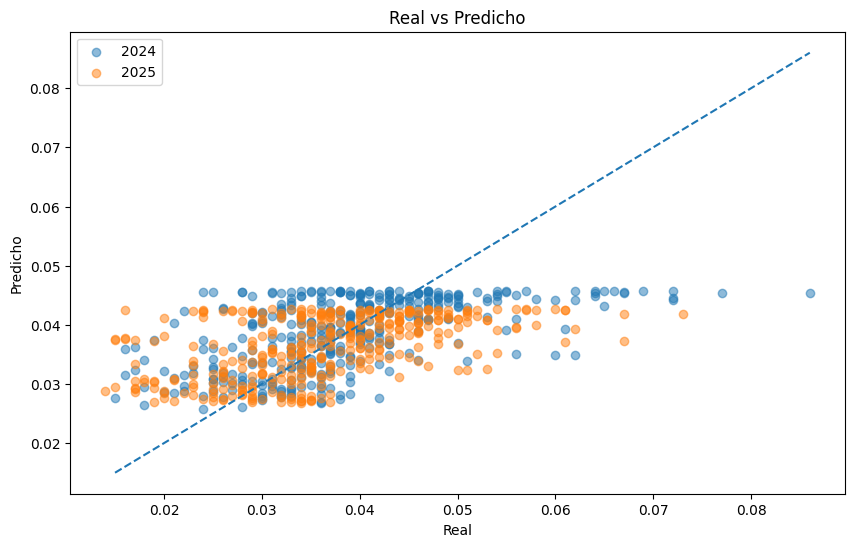

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(y_2024, y_pred_2024, alpha=0.5, label="2024")
plt.scatter(y_2025, y_pred_2025, alpha=0.5, label="2025")

plt.plot([min(y_2024), max(y_2024)],
         [min(y_2024), max(y_2024)],
         linestyle="--")

plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho")
plt.legend()
plt.show()

Gráfico de residuos

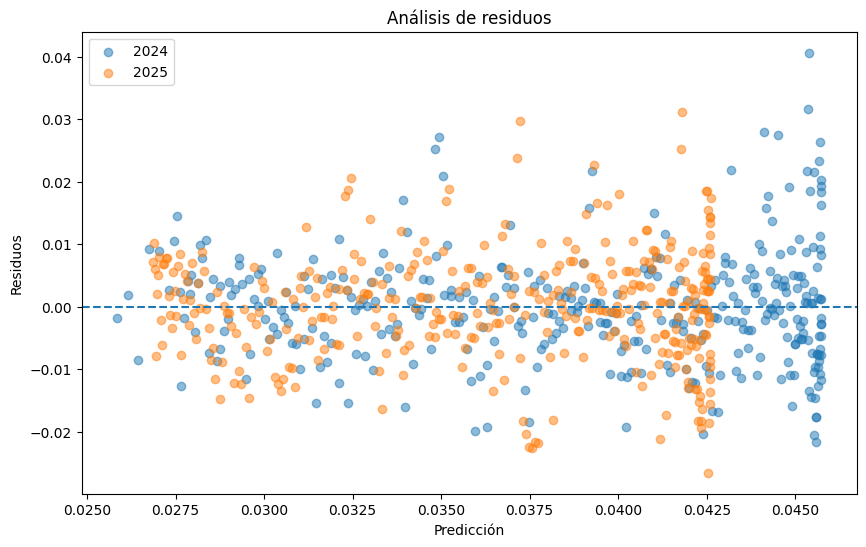

In [14]:
res_2024 = y_2024 - y_pred_2024
res_2025 = y_2025 - y_pred_2025

plt.figure(figsize=(10,6))

plt.scatter(y_pred_2024, res_2024, alpha=0.5, label="2024")
plt.scatter(y_pred_2025, res_2025, alpha=0.5, label="2025")

plt.axhline(0, linestyle="--")

plt.xlabel("Predicción")
plt.ylabel("Residuos")
plt.title("Análisis de residuos")
plt.legend()
plt.show()

Histogramas de errores

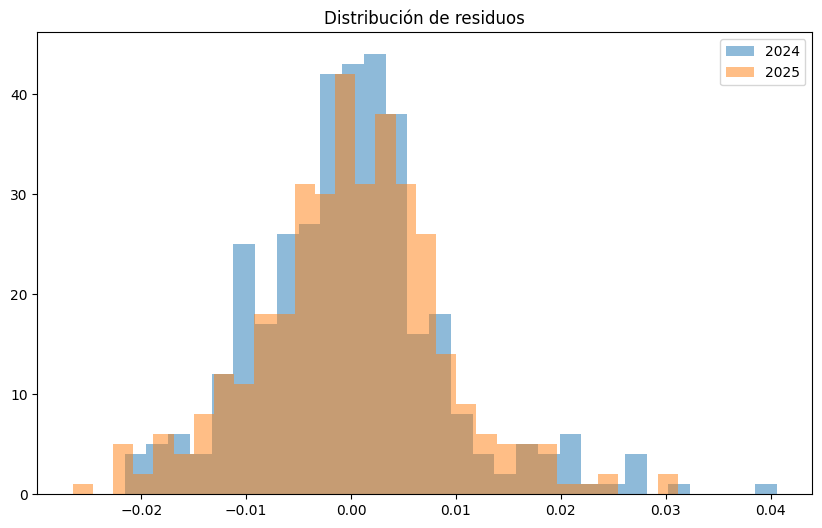

In [15]:
plt.figure(figsize=(10,6))

plt.hist(res_2024, bins=30, alpha=0.5, label="2024")
plt.hist(res_2025, bins=30, alpha=0.5, label="2025")

plt.title("Distribución de residuos")
plt.legend()
plt.show()

**3. Resultados**

Se obtuvo los siguientes resultados:


*   2024 -> R2: 0.2957, RMSE: 0.0091, MAE: 0.0067
*   2025 -> R2: 0.2515, RMSE: 0.0088, MAE: 0.0066



**4. Discusión**





Los resultados obtenidos evidencian una baja capacidad explicativa del modelo de regresión polinómica, con valores de R² de 0.2957 para 2024 y 0.2515 para 2025. Esto indica que aproximadamente el 70–75% de la variabilidad en la concentración de ozono no es explicada por el modelo, lo que sugiere que el uso exclusivo del día del año como variable predictora resulta insuficiente.

Desde una perspectiva ambiental, estos resultados son coherentes con la naturaleza del ozono troposférico. A diferencia de contaminantes primarios, el ozono es un contaminante secundario cuya formación depende de múltiples factores simultáneos, entre los que destacan la radiación solar, la temperatura, la velocidad del viento y la disponibilidad de precursores químicos como NOₓ y COV. En consecuencia, un modelo univariable basado únicamente en el tiempo no logra capturar la complejidad de estos procesos.
En términos de error, los valores de RMSE (0.0091 en 2024 y 0.0088 en 2025) y MAE (0.0067 en 2024 y 0.0066 en 2025) indican que, si bien el modelo presenta errores absolutos relativamente bajos, estos deben interpretarse con cautela. La magnitud reducida del error puede estar influenciada por la escala de la variable (concentraciones en ppm), por lo que no necesariamente refleja un buen ajuste del modelo. De hecho, la combinación de bajo R² con bajo error absoluto sugiere que el modelo tiende a aproximarse a un valor promedio, sin capturar adecuadamente la variabilidad ni los picos de concentración.


**5. Referencias bibliográficas**

[1] Seinfeld JH, Pandis SN. Atmospheric Chemistry and Physics. 3rd ed. New York: Wiley; 2016.

[2] U.S. Environmental Protection Agency. Air Quality System Data. 2024

[3] Hastie T, Tibshirani R, Friedman J. The Elements of Statistical Learning. New York: Springer; 2009.

[4] Montgomery DC, Peck EA, Vining GG. Introduction to Linear Regression Analysis. 5th ed. Wiley; 2012.

**6. Referencias IEEE**

[1] U.S. Environmental Protection Agency, “Air Quality System (AQS) Data,” 2024.

[2] J. H. Seinfeld and S. N. Pandis, Atmospheric Chemistry and Physics, 3rd ed. Wiley, 2016.

[3] T. Hastie, R. Tibshirani and J. Friedman, The Elements of Statistical Learning, Springer, 2009.

[4] D. Montgomery, E. Peck, and G. Vining, Introduction to Linear Regression Analysis, Wiley, 2012.